# 1d CIR process

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'

import sys
sys.path.insert(0, os.path.abspath('..'))

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import optax

import flax
import flax.linen as nn

from src.consistency_bridge import ConsistencyBridge

from src.models import ScoreMLP, ConservativeMLP
from src.plotting import plot_trajectories_1d

## define reference process

In [2]:
a = 1.0 
b = 1.0 
sigma = 1.0 

def base_drift(x, t):
    return a * (b - x)

def sigma_fn(x,t):
    return sigma * jnp.sqrt(jnp.maximum(x, 0.0))

def apply_sigma_fn(x,t):
    s = sigma_fn(x,t)
    def apply_sigma(dB_t):
        return s @ dB_t
    return s, apply_sigma

## Train Consistency Bridge

In [ ]:
d = 1

shape = (d,)

# start and end points
x_0 = jnp.array([2.0])
x_T = jnp.array([2.0])

T = 1.0

# model = ScoreMLP(
#     dim_hidden=(128,128), #(256, 256, 256), #(128, 128),
#     emb_dim_hidden=(64,64), #(128, 128), #(64, 64),
#     activation=nn.relu,
#     out_dim=d
# )

model = ConservativeMLP(
    dim_hidden=(128, 128),
    emb_dim_hidden=(64, 64),
    activation=nn.gelu,
)

bridge_config = {
        'base_drift': False,
        'guiding_type': 'brownian',
        'decay_coeff': False,
        'sampler': 'euler',
    }

bridge = ConsistencyBridge(
    shape=shape,
    x_0=x_0,
    x_T=x_T,
    base_drift_fn=base_drift,
    sigma_fn=sigma_fn,
    model=model,
    bridge_config=bridge_config,
    T=T
)

sigma_fn(x_0, 0.0), sigma_fn(x_T, T)

(Array([1.4142135], dtype=float32), Array([1.4142135], dtype=float32))

Training: 100%|████████████████████████| 1000/1000 [00:51<00:00, 19.35step/s, loss=3.1201e+00, ema_grad_norm=1.5701e+00]


Training finished.


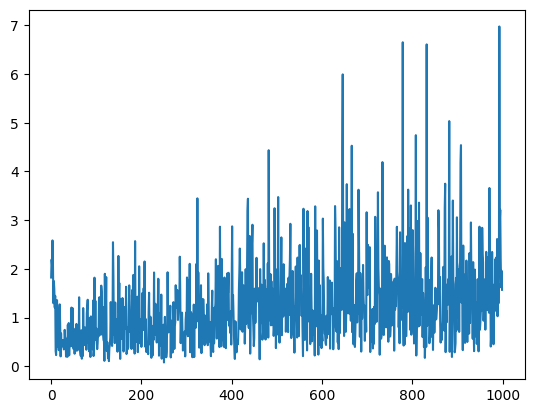

In [4]:
train_config = {
    'num_steps': 500,        # number of discretisation steps
    'num_outer_iterations': 1_000, #  # number of outer iterations
    'num_inner_iterations': 1,      # number of inner iterations
    'traj_batch_size': 64,          # number of trajectories per outer iteration
    'train_batch_size': 20_000, #       # number of training samples per inner iteration
    'lr': 1e-4, #                   # learning rate
    'ema_rate': 1.0,  # ema rate: 1.0 means no ema
    'grad_ema_rate': 1.0,
    'jacobian_method': 'euler', 
    'beta_schedule': 'average', # 'average', 'beta', 'endpoint', 'next_step',
    'B_ratio': 0.95,
    'ckpt_freq': 100,          # frequency of checkpoints
    'STL_adjustments': False, 
}

key = jax.random.PRNGKey(0)
state, ema_params_lst, ema_grad_norms = bridge.train(key, train_config)

plt.plot(ema_grad_norms)

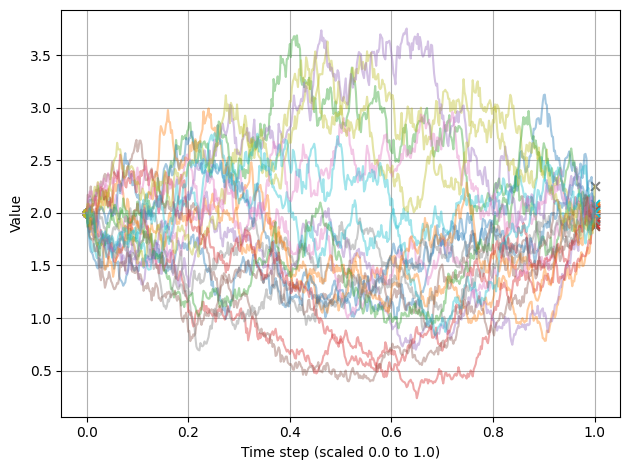

In [5]:
num_trajs = 20
num_steps = 500
key = jax.random.PRNGKey(0)
sample_keys = jax.random.split(key, num_trajs)

idx = -1
ema_params = ema_params_lst[idx]  # use the last ema parameters

ts = jnp.linspace(0, T, num_steps + 1)
x_traj, drift_traj, dB_t_traj = jax.vmap(
        bridge.sample_controlled_sde,
        in_axes=(0, None, None)
        )(sample_keys, ema_params, num_steps) # (B,N+1,d), (B,N,d), (B,N,d)

plot_trajectories_1d(x_traj[:20, :], alpha=0.5)